## 2.1. Разведочный анализ данных (EDA)

Загружу данные и посмотрю как они выглядят

In [14]:
import pandas as pd

In [15]:
df = pd.read_csv('retail_sales_mock_data.csv',
                 index_col = 'Date', parse_dates = True)
df.head()

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


Статистическое описание

Видно, что продажи ежемесячные

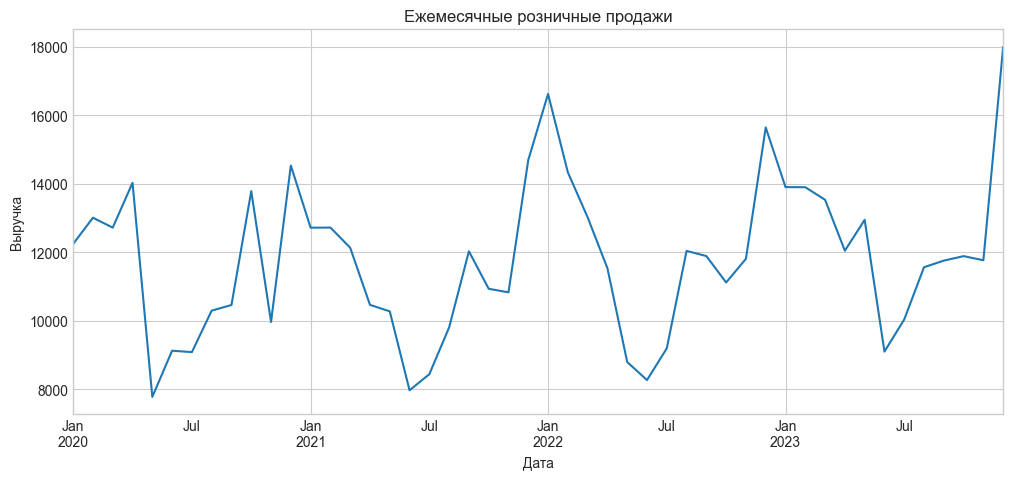

In [16]:
ax = df['SalesAmount'].plot(figsize = (12, 5), legend = None)
ax.set(title = 'Ежемесячные розничные продажи',
       xlabel = 'Дата',
       ylabel = 'Выручка');



Прослеживается сезонность, так как в январе каждого года видны характерные пики и спады в летнее время. Очень сильно бросается в глаза резкий рост выручки в декабре 2023 года, возможно были предновогодние акции или праздничная закупка перед новым годом. Выраженного тренда не наблюдается, так как выручка находится плюс минус на одном уровне

In [17]:
df['SalesAmount'].describe().round(2)

count       48.00
mean     11768.54
std       2257.54
min       7783.00
25%      10219.75
50%      11851.00
75%      13014.00
max      17996.00
Name: SalesAmount, dtype: float64

Из таблички видно, что датасет содержит 48 строк, я решила открыть его полностью и увидела, что данные ежемесячные за 4 года (гранулярность - месяц). Средняя выручка составляет 11 769 рублей. При этом разброс значений большой, так как стандартное отклонение 2258 рублей. Медиана составила 11 851 руб и близка к среднему, скорее всего не будет сильной асимметрии в распределении

межквартильный размах имеет формулу IQR = Q3 − Q1 = 13 014 - 10 219 = 2 794 руб, получила диапазон в котором находится средние 50% всех значений

Посчитаю границы выбросов:

Lower Bound = Q1 − 1.5×IQR = 10 220 − 1.5 × 2 794 = 6 029 руб

Upper Bound = Q3 + 1.5×IQR = 13 014 + 1.5 × 2 794 = 17 205 руб

Следовательно декабрь 2023 с выручкой приблизительно 18 000 руб является выбросом, так как выше верхней границы

In [18]:
print(f'Пропущенные значения: {df["SalesAmount"].isna().sum()}')


Пропущенные значения: 0


Пропущенных значений в данных нет, поэтому обработка данных не нужна

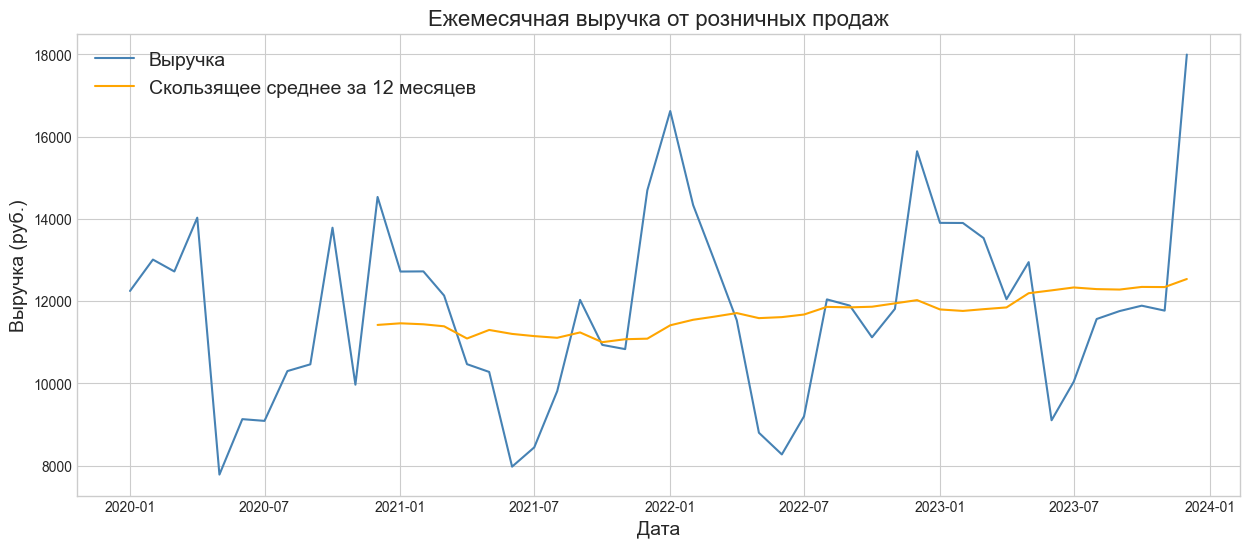

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(df['SalesAmount'], label='Выручка', color='steelblue')
plt.plot(df['SalesAmount'].rolling(window=12).mean(), label='Скользящее среднее за 12 месяцев', color='orange')

plt.legend(title='', loc='upper left', fontsize=14)

plt.xlabel('Дата', fontsize=14)
plt.ylabel('Выручка (руб.)', fontsize=14)
plt.title('Ежемесячная выручка от розничных продаж', fontsize=16)

plt.show()


Здесь уже тренд есть, но очень слабый. Средняя выручка выросла приблизительно с 11 000 до 12 500 рублей. На предыдущем графике тренд был не заметен, видимо из-за сильных сезонных колебаний

Можно сделать вывод, что ряд является нестационарным, так как есть явная сезонность и слабый восходящий тренд

Гистограмма

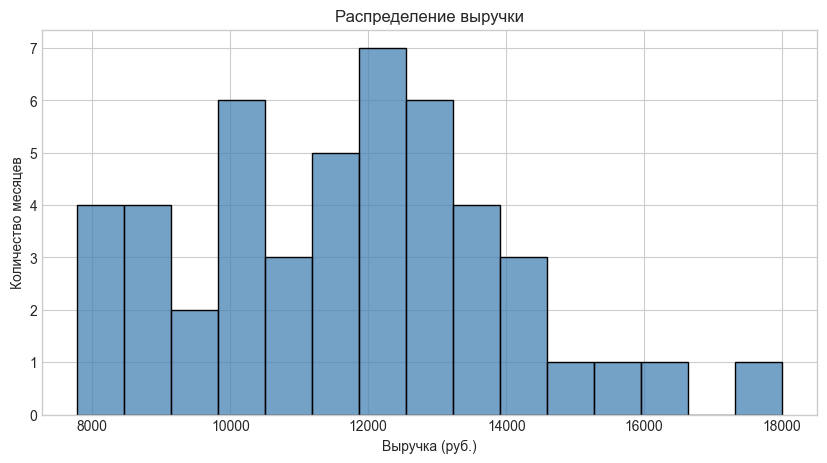

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df['SalesAmount'], bins=15, color='steelblue')
plt.title('Распределение выручки')
plt.xlabel('Выручка (руб.)')
plt.ylabel('Количество месяцев')
plt.show()

По гистограмме видно, что большинство месяцев выручка находилась в диапазоне от 10 000 до 13 000 руб. Один месяц с выручкой около 18 000 руб

Диаграмма размаха

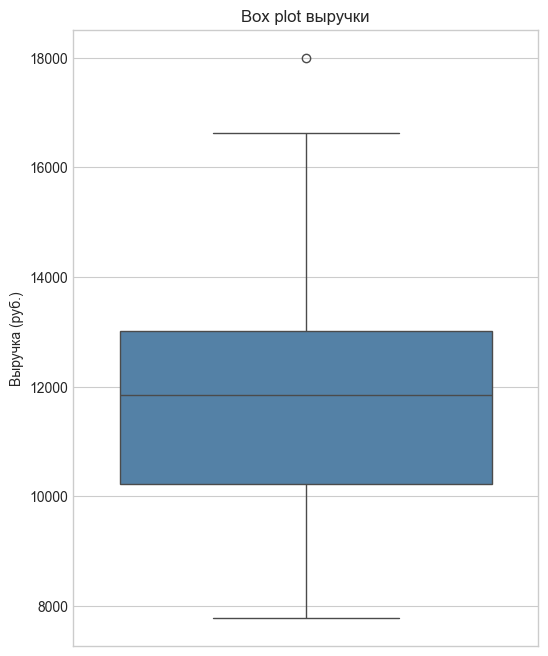

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 8))
sns.boxplot(y=df['SalesAmount'], color='steelblue')
plt.title('Box plot выручки')
plt.ylabel('Выручка (руб.)')
plt.show()

Синий прямоугольник охватывает средние 50% данных от 10 000 до 13 000. Линия внутри прямоугольника как раз медиана, в табличке чуть выше она как раз составила 11 850 рублей. Усы показывают нормальный диапазон значений. А кружок выше верхнего уса указывает на единичный выброс

 Анализ внешних факторов (Promotion и HolidayMonth)

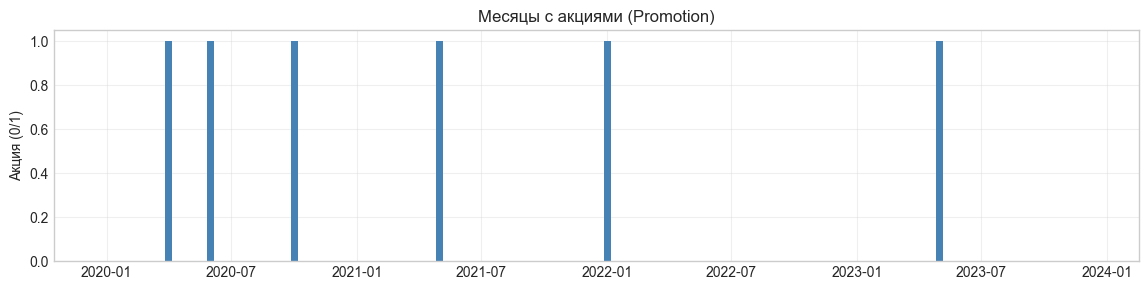

In [37]:
# Месяцы с акциями
plt.figure(figsize=(14, 3))
plt.bar(df.index, df['Promotion'], color='steelblue', width=10)
plt.title('Месяцы с акциями (Promotion)')
plt.ylabel('Акция (0/1)')
plt.grid(True, alpha=0.3)
plt.show()

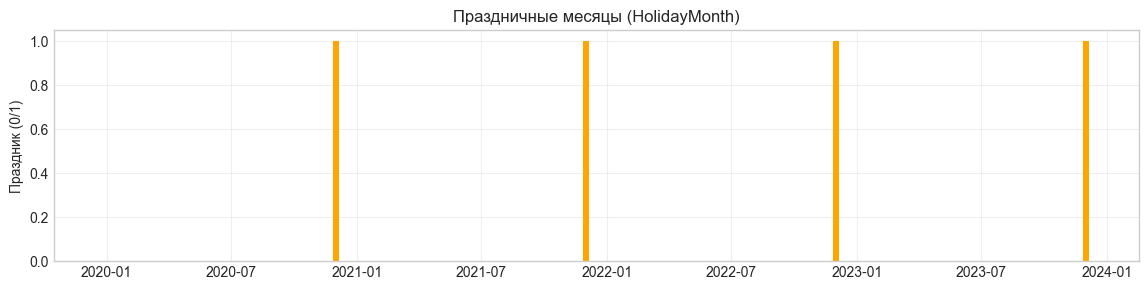

In [38]:
# Праздничные месяцы
plt.figure(figsize=(14, 3))
plt.bar(df.index, df['HolidayMonth'], color='orange', width=10)
plt.title('Праздничные месяцы (HolidayMonth)')
plt.ylabel('Праздник (0/1)')
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
# Список месяцев, где была акция или праздник
print(df[df['Promotion'] == 1])
print(df[df['HolidayMonth'] == 1])

            SalesAmount  Promotion  HolidayMonth
Date                                            
2020-04-01        14030          1             0
2020-06-01         9131          1             0
2020-10-01        13786          1             0
2021-05-01        10279          1             0
2022-01-01        16623          1             0
2023-05-01        12949          1             0
            SalesAmount  Promotion  HolidayMonth
Date                                            
2020-12-01        14534          0             1
2021-12-01        14696          0             1
2022-12-01        15645          0             1
2023-12-01        17996          0             1


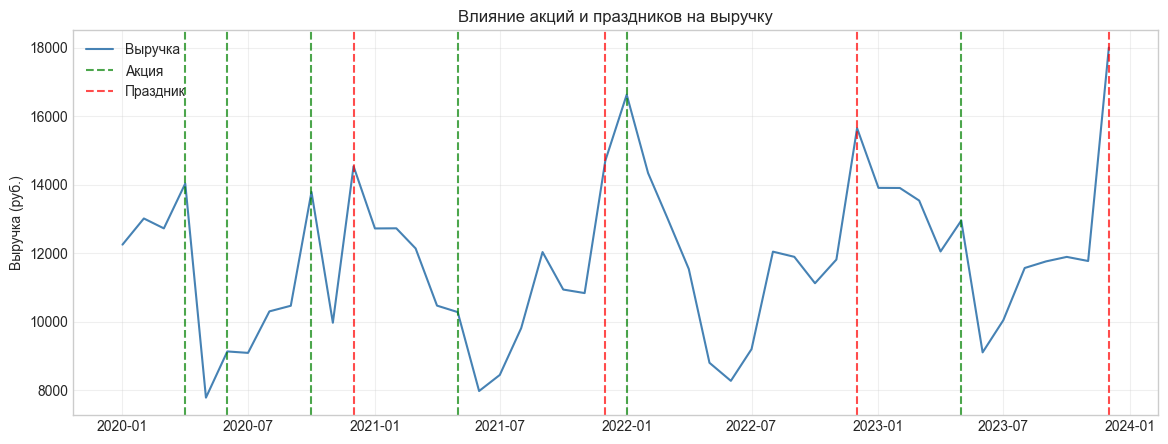

In [40]:
plt.figure(figsize=(14, 5))

# Выручка
plt.plot(df.index, df['SalesAmount'], color='steelblue', label='Выручка')

# Отмечаю акции вертикальными линиями
for date in df[df['Promotion'] == 1].index:
    plt.axvline(x=date, color='green', linestyle='--', alpha=0.7, label='Акция')

# Отмечаю праздники
for date in df[df['HolidayMonth'] == 1].index:
    plt.axvline(x=date, color='red', linestyle='--', alpha=0.7, label='Праздник')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.title('Влияние акций и праздников на выручку')
plt.ylabel('Выручка (руб.)')
plt.grid(True, alpha=0.3)
plt.show()


Вижу, что акции и праздники ни разу не пересекались. Праздничные месяцы совпадают со всеми декабрями, поэтому признак HolidayMonth дублирует по сути годовую сезонность и в эти месяцы выручка выше. Что касается акций, то они проводились в 6 месяцах из всех 48 и при этом в разное время года и нет четкой закономерности, но при этом акции сопровождают всплески продаж вне сезонного пика, это апрель и октябрь 2023, май 2023

Теплокарта (просто интересно)

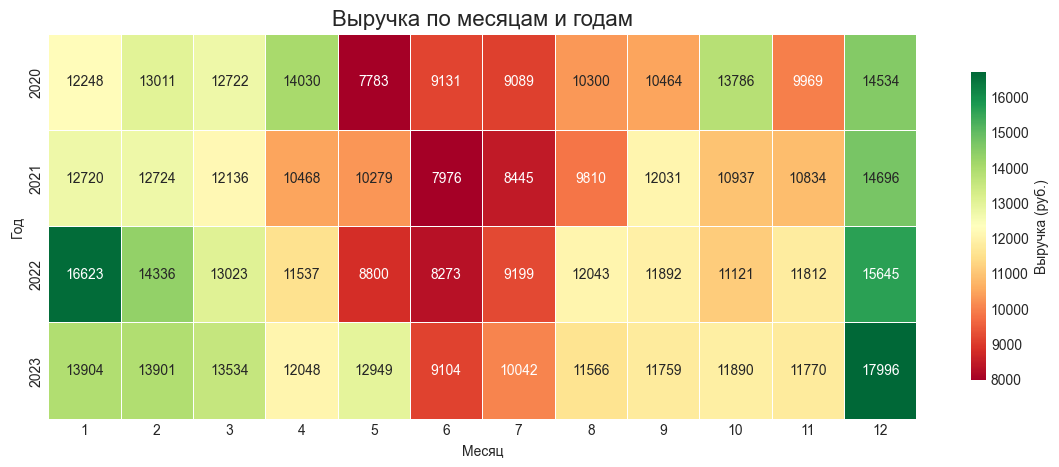

In [41]:
import seaborn as sns

# Создаю таблицу
df['Year'] = df.index.year
df['Month'] = df.index.month
pivot = df.pivot_table(values='SalesAmount', index='Year', columns='Month')

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='RdYlGn', robust=True,
            fmt='.0f', annot=True, linewidths=.5,
            cbar_kws={'shrink': .8, 'label': 'Выручка (руб.)'})

plt.title('Выручка по месяцам и годам', fontsize=16)
plt.xlabel('Месяц')
plt.ylabel('Год')
plt.show()

На тепловой карте подтвержается сезонность уже в который раз). Каждый год летом (май-июль) выручка минимальная, а зимой (декабрь-январь) максимальная. Декабрь 2023 с выручкой 17 996 руб абсолютный рекорд за весь период. Январь 2022 также выделяется на фоне остальных январей

Автокорреляция

<Figure size 1500x400 with 0 Axes>

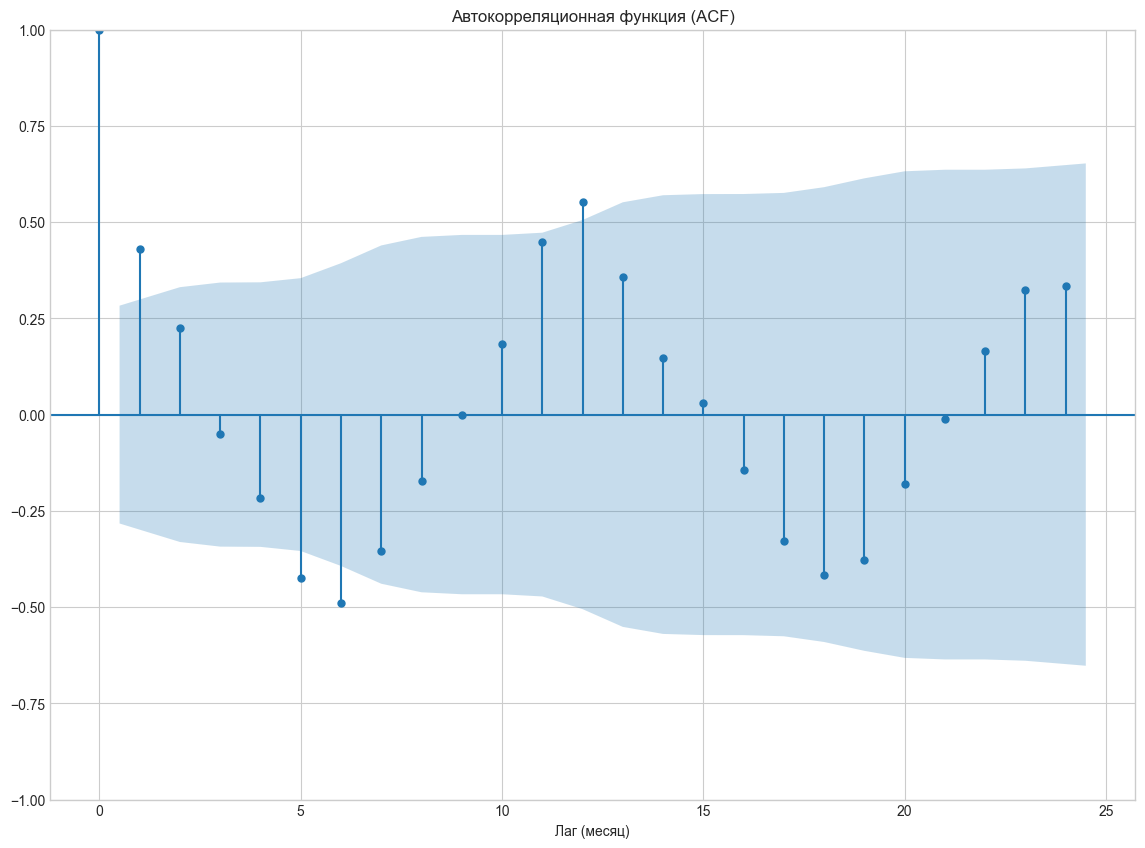

In [22]:
from statsmodels.graphics.tsaplots import plot_acf

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 4))
plot_acf(df['SalesAmount'].values.squeeze(), lags=24)
plt.title('Автокорреляционная функция (ACF)')
plt.xlabel('Лаг (месяц)')
plt.show()

Видны максимумы на лагах 6, 12, которые говорят о сезонности год. Для построения прогноза буду рассматривать признаки с лагами 1, 5, 6, 12. Также лаг 0 = 1, что говорит идеальная корреляция с самим собой. Отрицательные значения на лагах 6 и 7 указывают на то, что летние месяцы противоположны по характеру зимним, когда зимой пик, летом спад

<Figure size 1500x400 with 0 Axes>

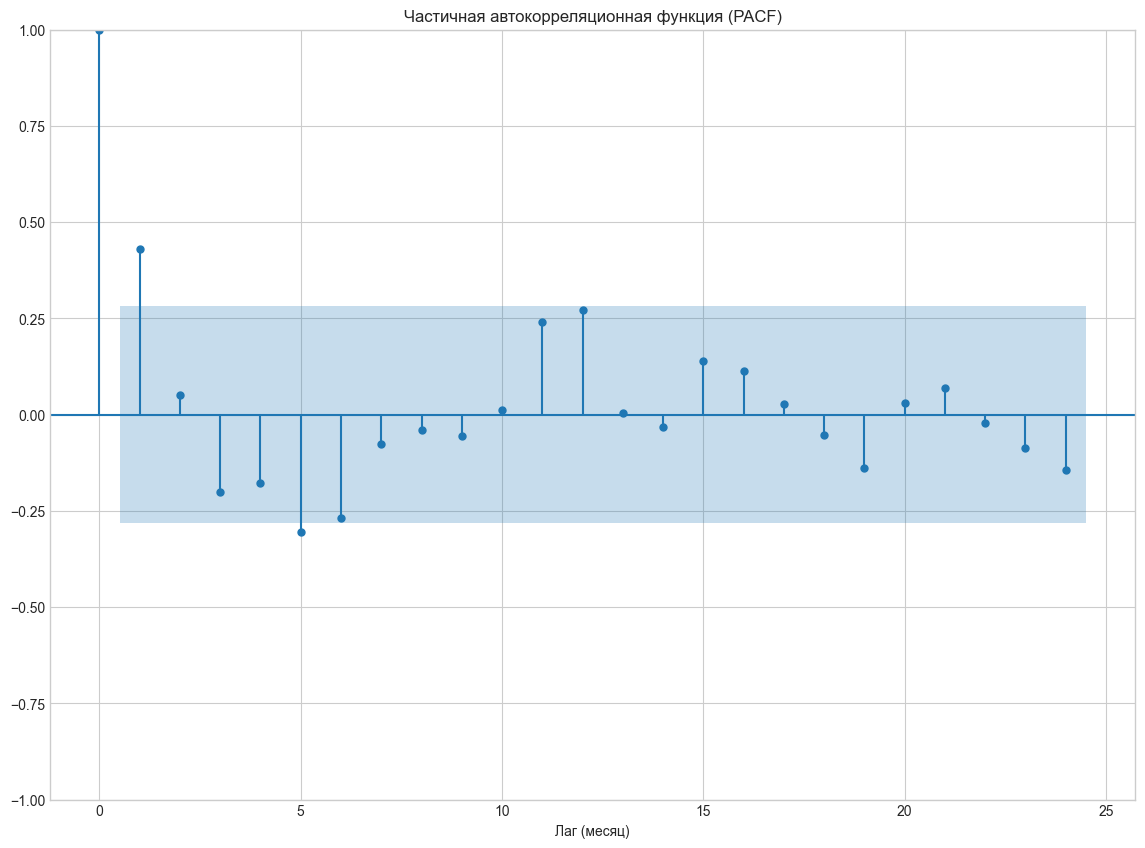

In [23]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(15, 4))
plot_pacf(df['SalesAmount'].values.squeeze(), lags=24)
plt.title('Частичная автокорреляционная функция (PACF)')
plt.xlabel('Лаг (месяц)')
plt.show()

На графике значимый пик наблюдается только на лаге 1 значит, что текущее значение выручки напрямую зависит только от предыдущего месяца. Остальные лаги в основном находятся внутри голубой области и статистически незначим

Тест Дики-Фуллера

In [24]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['SalesAmount'], autolag='AIC')
print(f'p-value: {result[1]:.4f}')

if result[1] < 0.05:
    print('Ряд стационарный')
else:
    print('Ряд нестационарный')

p-value: 0.0002
Ряд стационарный


C:\Users\Алина\AppData\Local\Temp\ipykernel_6528\841225114.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(df['SalesAmount'], autolag='AIC')


Тест Дики-Фуллера показал p-value = 0.0002, что меньше 0.05, значит ряд стационарный. Но на графиках видна сезонность, поэтому ряд нестационарный

1. seasonal_decompose

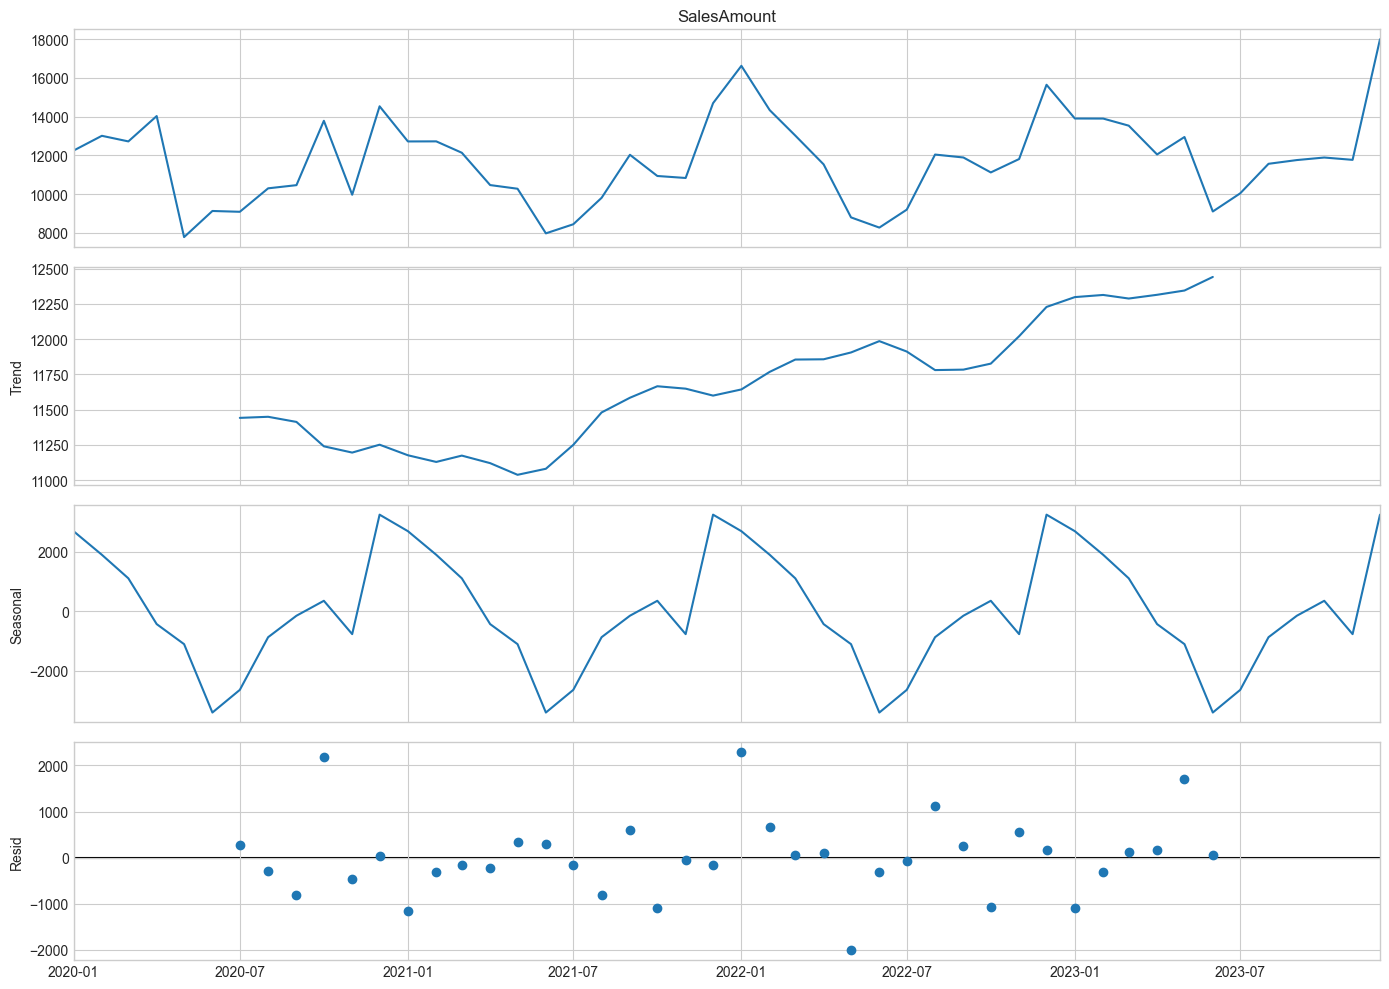

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams

rcParams['figure.figsize'] = 14, 10

decompose = seasonal_decompose(df['SalesAmount'], model='additive', period=12)
decompose.plot()
plt.show()

Тренд имеет плавный рост выручки приблизительно с 11 000 до 12 500 за 4 года. Сезонность выражена, так как повторяется годовой паттерн (пики зимой в январе и спад летом). Что касается остатков, то они случайные, разброс остатков одинаковый на всем периоде и без перекосов

Тренд не такой гладкий, а сезонность прерывистая, может попробовать мультипликативную модель запустить на тех же данных

2. FFT

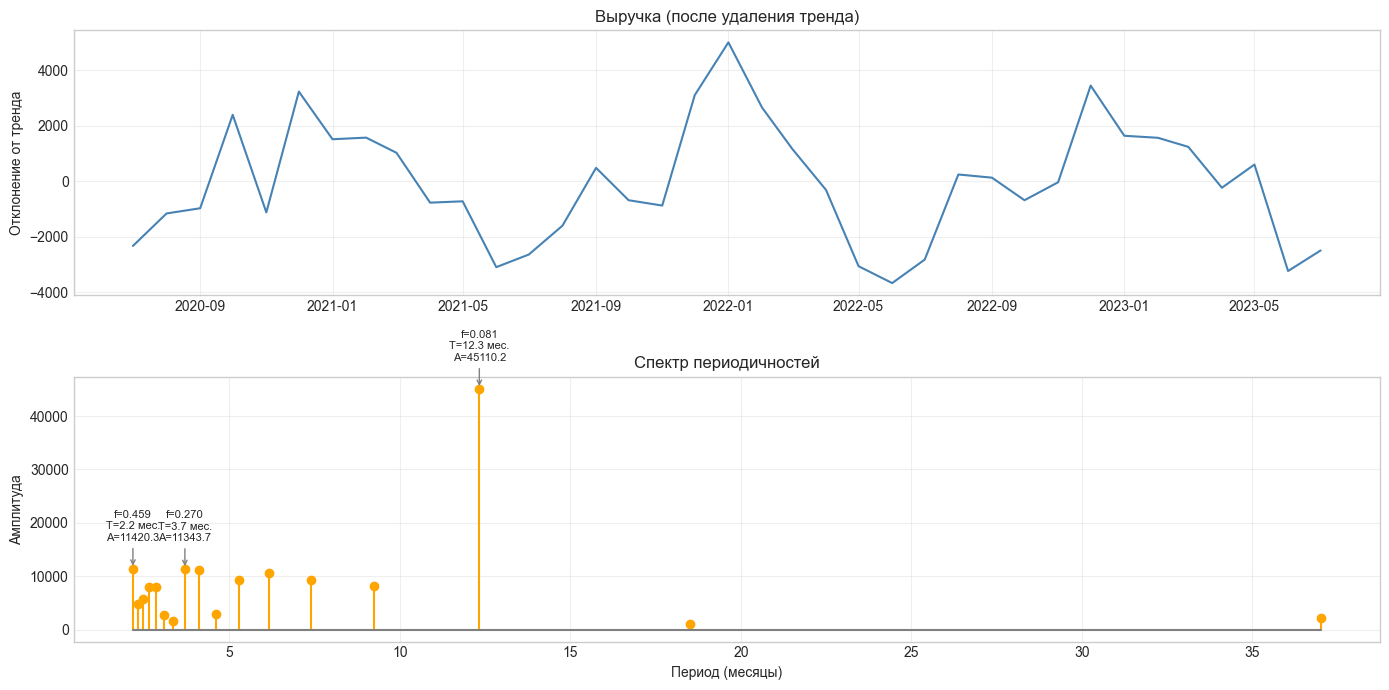

In [26]:
from scipy.fft import fft, fftfreq
import numpy as np

# Убираю тренд перед применением FFT с помощью скользящего среднего
sales_detrended = df['SalesAmount'] - df['SalesAmount'].rolling(12, center=True).mean()
sales_detrended = sales_detrended.dropna()

# Применяю быстрое преобразование Фурье
dt = 1  # шаг = 1 месяц
n = len(sales_detrended)
fft_vals = fft(sales_detrended.values)
freqs = fftfreq(n, dt)

# Беру только положительные частоты и перевожу в периоды
power = np.abs(fft_vals[:n//2])
freqs_pos = freqs[:n//2]
periods = 1 / freqs_pos[freqs_pos > 0]
power_pos = power[freqs_pos > 0]

fig, axs = plt.subplots(2, 1, figsize=(14, 7))

# Показываю ряд после удаления тренда
axs[0].plot(sales_detrended.index, sales_detrended.values, color='steelblue')
axs[0].set_title('Выручка (после удаления тренда)')
axs[0].set_ylabel('Отклонение от тренда')
axs[0].grid(True, alpha=0.3)

# Строю спектр
mask = (periods >= 2) & (periods <= 48)
axs[1].stem(periods[mask], power_pos[mask], linefmt='orange', markerfmt='o', basefmt='gray')
axs[1].set_xlabel('Период (месяцы)')
axs[1].set_ylabel('Амплитуда')
axs[1].set_title('Спектр периодичностей')
axs[1].grid(True, alpha=0.3)

# Подписываю самые сильные пики на спектре
for f in freqs[np.argsort(power)[-3:][::-1]]:
    if f > 0.01:
        period = 1/f
        amp = power[np.argmin(np.abs(freqs - f))]
        label = f'f={f:.3f}\nT={period:.1f} мес.\nA={amp:.1f}'
        axs[1].annotate(label,
                       xy=(period, amp), xytext=(0, 20), textcoords='offset points',
                       fontsize=8, ha='center',
                       arrowprops=dict(arrowstyle='->', color='gray'))


plt.tight_layout()
plt.show()


добавить описание, глянуть записи лекции